In [1]:
import os
import glob
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

import timm

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Using device:", DEVICE)

DATA_ROOT = "/Users/yaseenahmed/Documents/ML Project/MRNet-v1/MRNet-v1.0"
OOD_ROOT = "/Users/yaseenahmed/Documents/ML Project/OOD_images"

PLANES = ["sagittal", "coronal", "axial"]

IMG_SIZE = 224
BATCH_SIZE = 2
NUM_EPOCHS = 8
LEARNING_RATE = 1e-5
NUM_WORKERS = 0
NUM_SLICES = 2
THRESHOLD = 0.5
BEST_MODEL_PATH = "best_multiplane_vit_cls.pth"

Using device: mps


In [3]:
def load_labels(data_root, split):
    abnormal_path = os.path.join(data_root, f"{split}-abnormal.csv")
    acl_path = os.path.join(data_root, f"{split}-acl.csv")
    meniscus_path = os.path.join(data_root, f"{split}-meniscus.csv")

    abnormal_df = pd.read_csv(abnormal_path, header=None, names=["id", "abnormal"])
    acl_df = pd.read_csv(acl_path, header=None, names=["id", "acl"])
    meniscus_df = pd.read_csv(meniscus_path, header=None, names=["id", "meniscus"])

    merged_df = abnormal_df.merge(acl_df, on="id").merge(meniscus_df, on="id")

    labels = {}
    for _, row in merged_df.iterrows():
        exam_id = f"{int(row['id']):04d}"
        labels[exam_id] = [
            float(row["abnormal"]),
            float(row["acl"]),
            float(row["meniscus"])
        ]

    return labels

In [4]:
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

valid_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

In [5]:
class MRNetMultiPlaneDataset(Dataset):
    def __init__(self, data_root, split="train", num_slices=3, transform=None):
        self.data_root = data_root
        self.split = split
        self.num_slices = num_slices
        self.transform = transform
        self.planes = ["sagittal", "coronal", "axial"]

        self.labels = load_labels(data_root, split)
        self.exam_ids = sorted(list(self.labels.keys()))

    def __len__(self):
        return len(self.exam_ids)

    def normalize_slice(self, img):
        img = img.astype(np.float32)
        img_min = img.min()
        img_max = img.max()

        if img_max - img_min > 1e-8:
            img = (img - img_min) / (img_max - img_min)
        else:
            img = np.zeros_like(img, dtype=np.float32)

        img = (img * 255.0).clip(0, 255).astype(np.uint8)
        return img

    def get_slice_indices(self, num_total_slices):
        if self.num_slices >= num_total_slices:
            return np.arange(num_total_slices)
        return np.linspace(0, num_total_slices - 1, self.num_slices, dtype=int)

    def load_plane_volume(self, exam_id, plane):
        volume_path = os.path.join(self.data_root, self.split, plane, f"{exam_id}.npy")
        volume = np.load(volume_path)

        slice_indices = self.get_slice_indices(volume.shape[0])
        slice_tensors = []

        for s_idx in slice_indices:
            img = volume[s_idx]
            img = self.normalize_slice(img)
            pil_img = Image.fromarray(img).convert("RGB")

            if self.transform:
                pil_img = self.transform(pil_img)

            slice_tensors.append(pil_img)

        return torch.stack(slice_tensors, dim=0)  # (S, 3, H, W)

    def __getitem__(self, idx):
        exam_id = self.exam_ids[idx]

        sagittal = self.load_plane_volume(exam_id, "sagittal")
        coronal = self.load_plane_volume(exam_id, "coronal")
        axial = self.load_plane_volume(exam_id, "axial")

        label = torch.tensor(self.labels[exam_id], dtype=torch.float32)

        return sagittal, coronal, axial, label, exam_id

In [6]:
train_dataset = MRNetMultiPlaneDataset(
    data_root=DATA_ROOT,
    split="train",
    num_slices=NUM_SLICES,
    transform=train_transform
)

valid_dataset = MRNetMultiPlaneDataset(
    data_root=DATA_ROOT,
    split="valid",
    num_slices=NUM_SLICES,
    transform=valid_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("Train samples:", len(train_dataset))
print("Valid samples:", len(valid_dataset))

Train samples: 1130
Valid samples: 120


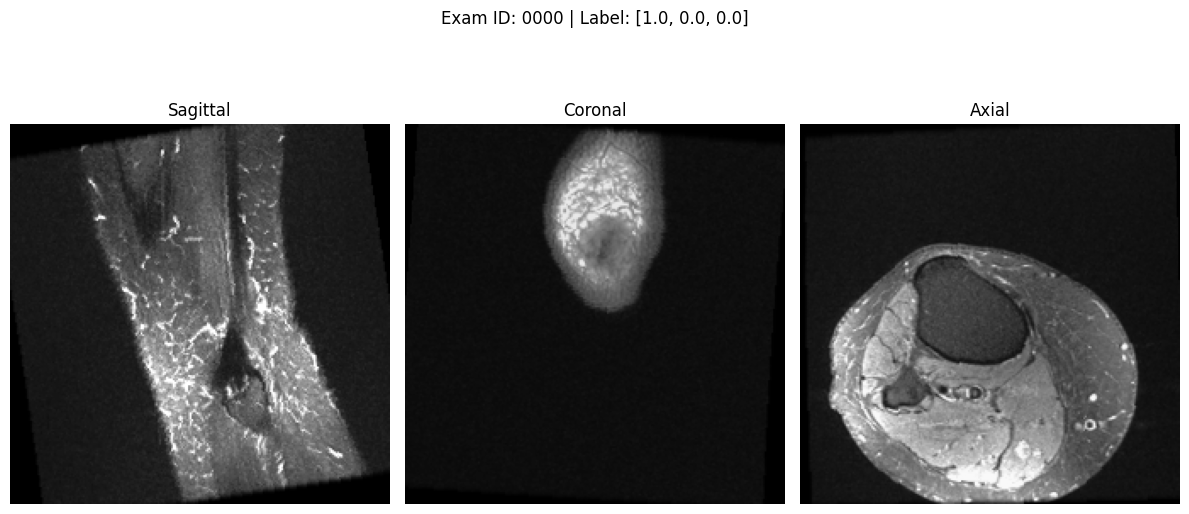

In [7]:
def denormalize_image(tensor_img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = tensor_img.cpu() * std + mean
    img = img.clamp(0, 1)
    return img.permute(1, 2, 0).numpy()

sagittal, coronal, axial, label, exam_id = train_dataset[0]

plane_dict = {
    "Sagittal": sagittal,
    "Coronal": coronal,
    "Axial": axial
}

plt.figure(figsize=(12, 6))
plot_idx = 1

for plane_name, plane_tensor in plane_dict.items():
    mid_slice = len(plane_tensor) // 2
    plt.subplot(1, 3, plot_idx)
    plt.imshow(denormalize_image(plane_tensor[mid_slice]))
    plt.title(f"{plane_name}")
    plt.axis("off")
    plot_idx += 1

plt.suptitle(f"Exam ID: {exam_id} | Label: {label.tolist()}")
plt.tight_layout()
plt.show()

In [8]:
def compute_pos_weights(dataset):
    all_labels = []

    for i in range(len(dataset)):
        _, _, _, label, _ = dataset[i]
        all_labels.append(label.numpy())

    all_labels = np.array(all_labels)
    positives = all_labels.sum(axis=0)
    negatives = len(all_labels) - positives

    pos_weight = negatives / (positives + 1e-8)
    return torch.tensor(pos_weight, dtype=torch.float32)

pos_weights = compute_pos_weights(train_dataset).to(DEVICE)
print("Positive class weights:", pos_weights)

Positive class weights: tensor([0.2377, 4.4327, 1.8463], device='mps:0')


In [9]:
class ViTMultiPlaneFusion(nn.Module):
    def __init__(self, model_name="vit_small_patch16_224", num_classes=3):
        super().__init__()

        self.backbone = timm.create_model(
            model_name,
            pretrained=True,
            num_classes=num_classes
        )

    def forward_one_plane(self, x):
        """
        x shape: (B, S, 3, H, W)
        Returns logits of shape (B, 3)
        """
        B, S, C, H, W = x.shape
        x = x.view(B * S, C, H, W)

        logits = self.backbone(x)       # (B*S, 3)
        logits = logits.view(B, S, -1)  # (B, S, 3)

        # Average over slices
        logits = logits.mean(dim=1)     # (B, 3)
        return logits

    def forward(self, sagittal, coronal, axial):
        sag_logits = self.forward_one_plane(sagittal)
        cor_logits = self.forward_one_plane(coronal)
        axi_logits = self.forward_one_plane(axial)

        # Average over planes
        fused_logits = (sag_logits + cor_logits + axi_logits) / 3.0
        return fused_logits

In [10]:
model = ViTMultiPlaneFusion(num_classes=3).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print(model)

ViTMultiPlaneFusion(
  (backbone): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=384, out_features=1536, bias=True)
  

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for sagittal, coronal, axial, labels, _ in tqdm(loader, desc="Training", leave=False):
        sagittal = sagittal.to(device)
        coronal = coronal.to(device)
        axial = axial.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(sagittal, coronal, axial)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)

    return total_loss / len(loader.dataset)

In [12]:
model = ViTMultiPlaneFusion(num_classes=3).to(DEVICE)

for param in model.backbone.parameters():
    param.requires_grad = False

# unfreeze only last 2 transformer blocks
for block in model.backbone.blocks[-2:]:
    for param in block.parameters():
        param.requires_grad = True

# unfreeze head
for param in model.backbone.head.parameters():
    param.requires_grad = True

In [13]:
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

In [14]:
class ViTMultiPlaneFusion(nn.Module):
    def __init__(self, model_name="vit_small_patch16_224", num_classes=3, dropout=0.3):
        super().__init__()

        self.backbone = timm.create_model(
            model_name,
            pretrained=True,
            num_classes=num_classes
        )
        self.dropout = nn.Dropout(dropout)

    def forward_one_plane(self, x):
        B, S, C, H, W = x.shape
        x = x.view(B * S, C, H, W)

        logits = self.backbone(x)
        logits = logits.view(B, S, -1)

        logits = logits.mean(dim=1)
        logits = self.dropout(logits)
        return logits

    def forward(self, sagittal, coronal, axial):
        sag_logits = self.forward_one_plane(sagittal)
        cor_logits = self.forward_one_plane(coronal)
        axi_logits = self.forward_one_plane(axial)

        fused_logits = (sag_logits + cor_logits + axi_logits) / 3.0
        return fused_logits

In [15]:
def evaluate_model(model, loader, criterion, device, threshold=0.5):
    model.eval()
    total_loss = 0.0

    all_labels = []
    all_probs = []
    all_preds = []
    all_ids = []

    with torch.no_grad():
        for sagittal, coronal, axial, labels, exam_ids in tqdm(loader, desc="Evaluating", leave=False):
            sagittal = sagittal.to(device)
            coronal = coronal.to(device)
            axial = axial.to(device)
            labels = labels.to(device)

            outputs = model(sagittal, coronal, axial)
            loss = criterion(outputs, labels)

            probs = torch.sigmoid(outputs)
            preds = (probs >= threshold).float()

            total_loss += loss.item() * labels.size(0)

            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_ids.extend(exam_ids)

    avg_loss = total_loss / len(loader.dataset)

    all_labels = np.concatenate(all_labels, axis=0)
    all_probs = np.concatenate(all_probs, axis=0)
    all_preds = np.concatenate(all_preds, axis=0)

    class_names = ["abnormal", "acl", "meniscus"]
    metrics = {}

    for i, class_name in enumerate(class_names):
        y_true = all_labels[:, i]
        y_prob = all_probs[:, i]
        y_pred = all_preds[:, i]

        metrics[class_name] = {
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "auc_roc": roc_auc_score(y_true, y_prob)
        }

    return avg_loss, metrics, all_labels, all_probs, all_preds, all_ids

In [16]:
train_losses = []
valid_losses = []

best_val_loss = float("inf")
best_epoch = 0

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")

    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    valid_loss, valid_metrics, all_labels, all_probs, all_preds, all_ids = evaluate_model(
        model, valid_loader, criterion, DEVICE, threshold=THRESHOLD
    )

    scheduler.step()

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Valid Loss: {valid_loss:.4f}")

    for cls, cls_metrics in valid_metrics.items():
        print(f"\n{cls.upper()}")
        for metric_name, metric_value in cls_metrics.items():
            print(f"  {metric_name}: {metric_value:.4f}")

    if valid_loss < best_val_loss:
        best_val_loss = valid_loss
        best_epoch = epoch + 1
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"\nSaved best model to: {BEST_MODEL_PATH}")

print(f"\nBest validation loss: {best_val_loss:.4f} at epoch {best_epoch}")


Epoch 1/8


/var/folders/p4/cp7wz8hx5r91wbwpbs2q7brh0000gn/T/ipykernel_11491/1384901846.py:15: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Train Loss: 0.7723
Valid Loss: 1.0562

ABNORMAL
  accuracy: 0.4500
  precision: 0.8372
  recall: 0.3789
  f1: 0.5217
  auc_roc: 0.5802

ACL
  accuracy: 0.5333
  precision: 0.4167
  recall: 0.0926
  f1: 0.1515
  auc_roc: 0.5115

MENISCUS
  accuracy: 0.5333
  precision: 0.4688
  recall: 0.5769
  f1: 0.5172
  auc_roc: 0.5747

Saved best model to: best_multiplane_vit_cls.pth

Epoch 2/8


Train Loss: 0.7382
Valid Loss: 1.0024

ABNORMAL
  accuracy: 0.3833
  precision: 0.8621
  recall: 0.2632
  f1: 0.4032
  auc_roc: 0.6282

ACL
  accuracy: 0.5917
  precision: 0.5862
  recall: 0.3148
  f1: 0.4096
  auc_roc: 0.6369

MENISCUS
  accuracy: 0.5583
  precision: 0.4925
  recall: 0.6346
  f1: 0.5546
  auc_roc: 0.6027

Saved best model to: best_multiplane_vit_cls.pth

Epoch 3/8


Train Loss: 0.7092
Valid Loss: 1.0834

ABNORMAL
  accuracy: 0.3833
  precision: 0.8621
  recall: 0.2632
  f1: 0.4032
  auc_roc: 0.6535

ACL
  accuracy: 0.6083
  precision: 0.8182
  recall: 0.1667
  f1: 0.2769
  auc_roc: 0.6975

MENISCUS
  accuracy: 0.5583
  precision: 0.4898
  recall: 0.4615
  f1: 0.4752
  auc_roc: 0.6247

Epoch 4/8


Train Loss: 0.6980
Valid Loss: 0.9607

ABNORMAL
  accuracy: 0.5667
  precision: 0.8772
  recall: 0.5263
  f1: 0.6579
  auc_roc: 0.6728

ACL
  accuracy: 0.6500
  precision: 0.6579
  recall: 0.4630
  f1: 0.5435
  auc_roc: 0.7281

MENISCUS
  accuracy: 0.5667
  precision: 0.5000
  recall: 0.5192
  f1: 0.5094
  auc_roc: 0.6307

Saved best model to: best_multiplane_vit_cls.pth

Epoch 5/8


Train Loss: 0.6819
Valid Loss: 0.9966

ABNORMAL
  accuracy: 0.5417
  precision: 0.8571
  recall: 0.5053
  f1: 0.6358
  auc_roc: 0.6859

ACL
  accuracy: 0.6500
  precision: 0.7000
  recall: 0.3889
  f1: 0.5000
  auc_roc: 0.7393

MENISCUS
  accuracy: 0.6000
  precision: 0.5400
  recall: 0.5192
  f1: 0.5294
  auc_roc: 0.6389

Epoch 6/8


Train Loss: 0.6616
Valid Loss: 1.1514

ABNORMAL
  accuracy: 0.5333
  precision: 0.8679
  recall: 0.4842
  f1: 0.6216
  auc_roc: 0.6981

ACL
  accuracy: 0.6417
  precision: 0.8667
  recall: 0.2407
  f1: 0.3768
  auc_roc: 0.7508

MENISCUS
  accuracy: 0.5667
  precision: 0.5000
  recall: 0.2885
  f1: 0.3659
  auc_roc: 0.6423

Epoch 7/8


Train Loss: 0.6535
Valid Loss: 0.9449

ABNORMAL
  accuracy: 0.6167
  precision: 0.8769
  recall: 0.6000
  f1: 0.7125
  auc_roc: 0.7091

ACL
  accuracy: 0.6500
  precision: 0.6579
  recall: 0.4630
  f1: 0.5435
  auc_roc: 0.7595

MENISCUS
  accuracy: 0.5833
  precision: 0.5135
  recall: 0.7308
  f1: 0.6032
  auc_roc: 0.6448

Saved best model to: best_multiplane_vit_cls.pth

Epoch 8/8


Train Loss: 0.6428
Valid Loss: 1.0039

ABNORMAL
  accuracy: 0.6167
  precision: 0.8889
  recall: 0.5895
  f1: 0.7089
  auc_roc: 0.7179

ACL
  accuracy: 0.6750
  precision: 0.8000
  recall: 0.3704
  f1: 0.5063
  auc_roc: 0.7722

MENISCUS
  accuracy: 0.5917
  precision: 0.5273
  recall: 0.5577
  f1: 0.5421
  auc_roc: 0.6538

Best validation loss: 0.9449 at epoch 7


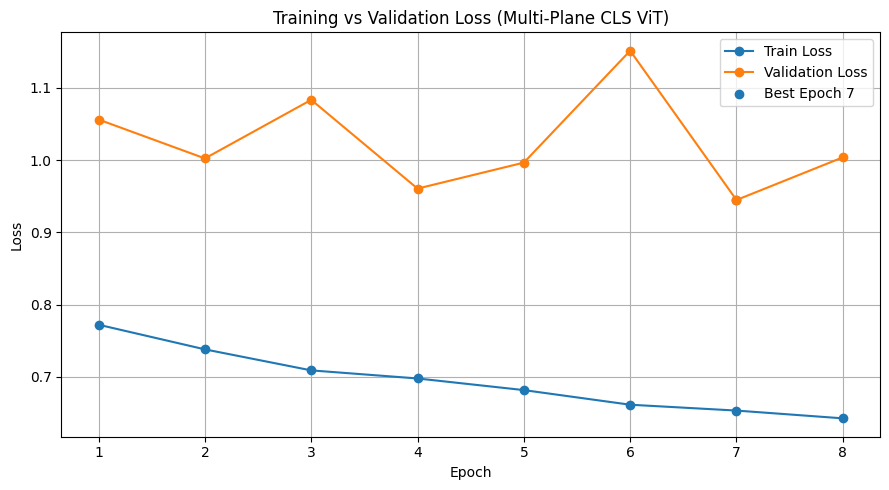

In [17]:
epochs = range(1, len(train_losses) + 1)
best_val = min(valid_losses)

plt.figure(figsize=(9, 5))
plt.plot(epochs, train_losses, marker='o', label="Train Loss")
plt.plot(epochs, valid_losses, marker='o', label="Validation Loss")
plt.scatter(best_epoch, best_val, label=f"Best Epoch {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Multi-Plane CLS ViT)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
best_model = ViTMultiPlaneFusion(num_classes=3).to(DEVICE)
best_model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
best_model.eval()

valid_loss, valid_metrics, all_labels, all_probs, all_preds, all_ids = evaluate_model(
    best_model, valid_loader, criterion, DEVICE, threshold=THRESHOLD
)

print("Final Validation Loss:", valid_loss)

for cls, cls_metrics in valid_metrics.items():
    print(f"\n{cls.upper()}")
    for metric_name, metric_value in cls_metrics.items():
        print(f"  {metric_name}: {metric_value:.4f}")

Final Validation Loss: 0.9448879609505335

ABNORMAL
  accuracy: 0.6167
  precision: 0.8769
  recall: 0.6000
  f1: 0.7125
  auc_roc: 0.7091

ACL
  accuracy: 0.6500
  precision: 0.6579
  recall: 0.4630
  f1: 0.5435
  auc_roc: 0.7595

MENISCUS
  accuracy: 0.5833
  precision: 0.5135
  recall: 0.7308
  f1: 0.6032
  auc_roc: 0.6448


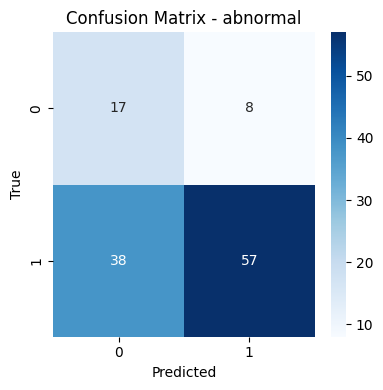

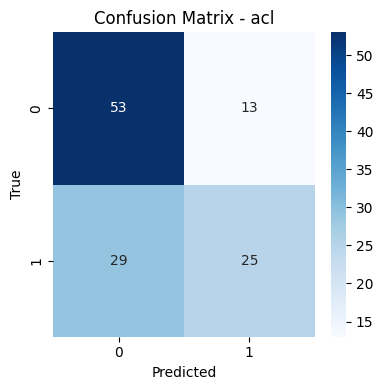

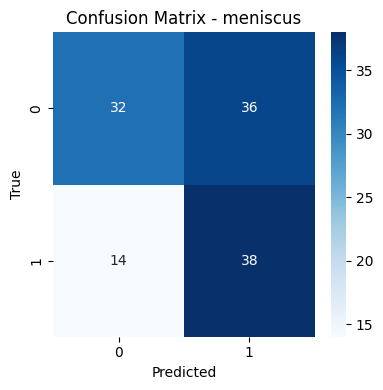

In [19]:
class_names = ["abnormal", "acl", "meniscus"]

for i, class_name in enumerate(class_names):
    cm = confusion_matrix(all_labels[:, i], all_preds[:, i])

    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {class_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

In [20]:
results_df = pd.DataFrame({
    "exam_id": all_ids,

    "abnormal_true": all_labels[:, 0],
    "abnormal_prob": all_probs[:, 0],
    "abnormal_pred": all_preds[:, 0],

    "acl_true": all_labels[:, 1],
    "acl_prob": all_probs[:, 1],
    "acl_pred": all_preds[:, 1],

    "meniscus_true": all_labels[:, 2],
    "meniscus_prob": all_probs[:, 2],
    "meniscus_pred": all_preds[:, 2],
})

results_df.to_csv("multiplane_validation_predictions.csv", index=False)
print("Saved multiplane_validation_predictions.csv")

Saved multiplane_validation_predictions.csv


In [21]:
class OODImageDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_paths = sorted(
            glob.glob(os.path.join(image_dir, "*.png")) +
            glob.glob(os.path.join(image_dir, "*.jpg")) +
            glob.glob(os.path.join(image_dir, "*.jpeg"))
        )
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, os.path.basename(image_path)

In [22]:
def run_ood_inference_multiplane(model, image_dir, transform, device, threshold=0.5):
    model.eval()

    ood_dataset = OODImageDataset(image_dir=image_dir, transform=transform)

    results = []
    class_names = ["abnormal", "acl", "meniscus"]

    with torch.no_grad():
        for image, filename in ood_dataset:
            # Make one image act like 3 planes, 1 slice each:
            # sagittal=(1,1,3,H,W), coronal=(1,1,3,H,W), axial=(1,1,3,H,W)
            image = image.unsqueeze(0).unsqueeze(0).to(device)

            outputs = model(image, image, image)
            probs = torch.sigmoid(outputs).squeeze(0).cpu().numpy()
            preds = (probs >= threshold).astype(int)

            result = {"filename": filename}
            for i, class_name in enumerate(class_names):
                result[f"{class_name}_prob"] = float(probs[i])
                result[f"{class_name}_pred"] = int(preds[i])

            results.append(result)

    return pd.DataFrame(results)

In [23]:
ood_results_df = run_ood_inference_multiplane(
    model=best_model,
    image_dir=OOD_ROOT,
    transform=valid_transform,
    device=DEVICE,
    threshold=THRESHOLD
)

ood_results_df

,filename,abnormal_prob,abnormal_pred,acl_prob,acl_pred,meniscus_prob,meniscus_pred
0,ACL_sag-2.png,0.379876,0,0.304483,0,0.456725,0
1,ACL_sag_1.jpg,0.844487,1,0.537997,1,0.741740,1
2,Meni_sag_2.jpg,0.738421,1,0.915432,1,0.929500,1
3,meni_coronal_1.png,0.238341,0,0.424204,0,0.364712,0
4,meni_sag_1.jpg,0.914391,1,0.720336,1,0.955069,1
5,normal_coronal.jpeg,0.076877,0,0.093702,0,0.046899,0
6,normal_sag_2.jpeg,0.141849,0,0.087291,0,0.225029,0


In [24]:
ood_results_df.to_csv("multiplane_ood_predictions.csv", index=False)
print("Saved multiplane_ood_predictions.csv")

Saved multiplane_ood_predictions.csv


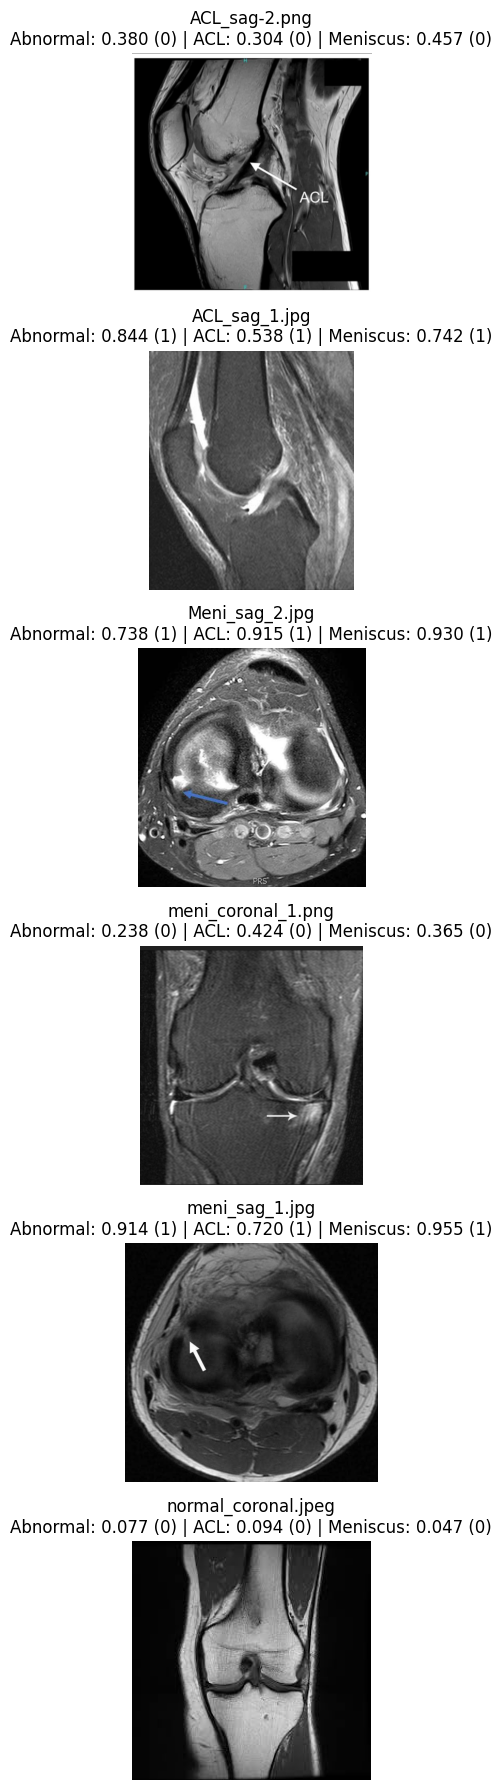

In [25]:
def show_ood_predictions(ood_root, results_df, max_images=6):
    image_files = results_df["filename"].tolist()[:max_images]

    plt.figure(figsize=(15, 3 * max_images))

    for i, filename in enumerate(image_files):
        image_path = os.path.join(ood_root, filename)
        img = Image.open(image_path).convert("RGB")

        row = results_df[results_df["filename"] == filename].iloc[0]

        title = (
            f"{filename}\n"
            f"Abnormal: {row['abnormal_prob']:.3f} ({row['abnormal_pred']}) | "
            f"ACL: {row['acl_prob']:.3f} ({row['acl_pred']}) | "
            f"Meniscus: {row['meniscus_prob']:.3f} ({row['meniscus_pred']})"
        )

        plt.subplot(max_images, 1, i + 1)
        plt.imshow(img)
        plt.title(title)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_ood_predictions(OOD_ROOT, ood_results_df, max_images=min(6, len(ood_results_df)))

In [26]:
metrics_rows = []
for cls, cls_metrics in valid_metrics.items():
    row = {"class": cls}
    row.update(cls_metrics)
    metrics_rows.append(row)

metrics_df = pd.DataFrame(metrics_rows)
metrics_df

,class,accuracy,precision,recall,f1,auc_roc
0,abnormal,0.616667,0.876923,0.600000,0.712500,0.709053
1,acl,0.650000,0.657895,0.462963,0.543478,0.759540
2,meniscus,0.583333,0.513514,0.730769,0.603175,0.644796


In [27]:
metrics_df.to_csv("multiplane_validation_metrics.csv", index=False)
print("Saved multiplane_validation_metrics.csv")

Saved multiplane_validation_metrics.csv
